# Plot Delta Functions

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy import stats

from confrdm.simulators.rdmc import simulate_rdmc_two_accumulators
from confrdm.simulators.rdm import simulate_rdm_two_accumulators
from confrdm.simulators.dmc import simulate_dmc


In [21]:
NUM_OBS = 10_000
T_MAX = 5000

In [22]:
def create_delta_plot(data):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    rt = data[:, 0]
    resp = data[:, 1]
    cond = data[:, 2]

    qs = np.linspace(0, 1, 19)[1:-1]

    mean_quantiles = np.array(
        [
            stats.mstats.mquantiles(
                rt[np.bitwise_and(resp == 1, cond == i)],
                qs,
                alphap=0.5,
                betap=0.5,
            )
            for i in (0, 1)
        ]
    )

    diff_quantiles = mean_quantiles[0, :] - mean_quantiles[1, :]

    ax.plot(mean_quantiles.mean(axis=0), diff_quantiles, "--o", color="black")

    ax.set_ylabel("Difference mean RT congruent vs. incongruent (ms)")
    ax.set_xlabel("Mean RT quantiles (ms)")
    
    fig.tight_layout()
    return fig, ax


def create_pushforward_plot(data):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 5))
    rt = data[:, 0]
    resp = data[:, 1]
    cond = data[:, 2]

    for i, ax in enumerate((ax1, ax2)):
        sns.histplot(
            rt[np.bitwise_and(resp == 1, cond == i)], color="darkgreen", alpha=0.5, ax=ax
        )
        sns.histplot(
            rt[np.bitwise_and(resp == 0, cond == i)], color="maroon", alpha=0.5, ax=ax
        )
        sns.despine(ax=ax)
        ax.vlines([rt[np.bitwise_and(resp == 1, cond == i)].mean(), rt[np.bitwise_and(resp == 0, cond == i)].mean()], ymin = 0, ymax = 0.5, color = ["darkgreen", "maroon"], linestyle = '-', 
            transform=ax.get_xaxis_transform())

        ax.text(
            0.9,
            0.9,
            f"Acc: {str(np.round(resp[cond == i].mean(), 2))}",
            horizontalalignment="center",
            verticalalignment="center",
            transform=ax.transAxes,
        )

        ax.spines['bottom'].set_position('zero')

        ax.set_ylabel("")
        ax.set_yticks([])
        ax.set_xlabel("Simulated RTs (milliseconds)") 

    ax1.set_title("Incongruent")
    ax2.set_title("Congruent")

    fig.tight_layout()

    return fig, (ax1, ax2)


def create_caf_plot(data, n_bins=5):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    rt = data[:, 0]
    resp = data[:, 1]
    cond = data[:, 2]

    color_dict = {
        0: "maroon",
        1: "darkgreen",
    }

    for i in np.unique(cond):
        # Select data for this condition
        mask = cond == i
        rt_cond = rt[mask]
        resp_cond = resp[mask]
        # Bin RTs for this condition
        bins = np.quantile(rt_cond, np.linspace(0, 1, n_bins + 1))
        bin_indices = np.digitize(rt_cond, bins, right=True) - 1
        # Ensure bin_indices are within range
        bin_indices = np.clip(bin_indices, 0, n_bins - 1)
        prop_resp = []
        bin_centers = []
        for b in range(n_bins):
            in_bin = bin_indices == b
            if np.any(in_bin):
                prop = resp_cond[in_bin].mean()
                center = rt_cond[in_bin].mean()
            else:
                prop = np.nan
                center = np.nan
            prop_resp.append(prop)
            bin_centers.append(center)
        ax.plot(range(1, n_bins + 1), prop_resp, marker="o", linestyle="-", color=color_dict[i])
        ax.set_xlabel("RT bin")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0, 1)
        ax.spines['bottom'].set_position('zero')
        ax.set_xticks(range(1, n_bins + 1))
        ax.set_yticks([0, 0.5, 1])
    fig.tight_layout()
    return fig, ax

## RDM

In [23]:
rng = np.random.default_rng(2026)

def simulate_rdm_conditions(**kwargs):
    v_congruent = kwargs.pop("v_slope_congruent")
    v_incongruent = kwargs.pop("v_slope_incongruent")
    s_congruent = kwargs.pop("s_true_congruent")
    s_incongruent = kwargs.pop("s_true_incongruent")

    data_congruent = simulate_rdm_two_accumulators(
        v_slope=v_congruent,
        s_true=s_congruent,
        num_obs=NUM_OBS // 2,
        rng=rng,
        **kwargs
    )

    data_incongruent = simulate_rdm_two_accumulators(
        v_slope=v_incongruent,
        s_true=s_incongruent,
        num_obs=NUM_OBS // 2,
        rng=rng,
        **kwargs
    )

    data_congruent["x"][:, 0] *= 1000
    data_incongruent["x"][:, 0] *= 1000
    
    condition = np.repeat([1, 0], data_congruent["x"].shape[0])

    return np.c_[np.vstack([data_congruent["x"], data_incongruent["x"]]), condition]

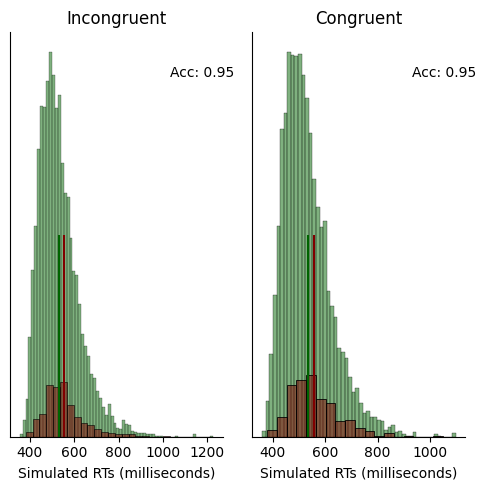

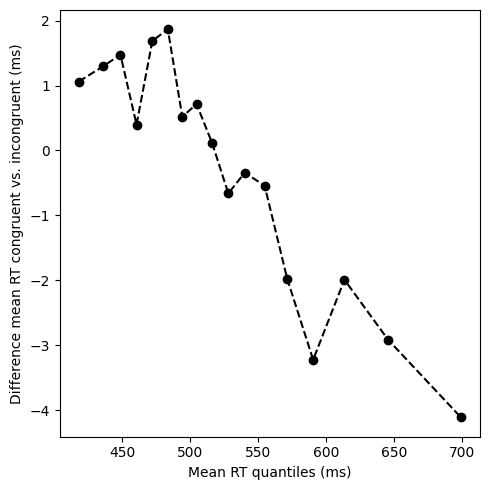

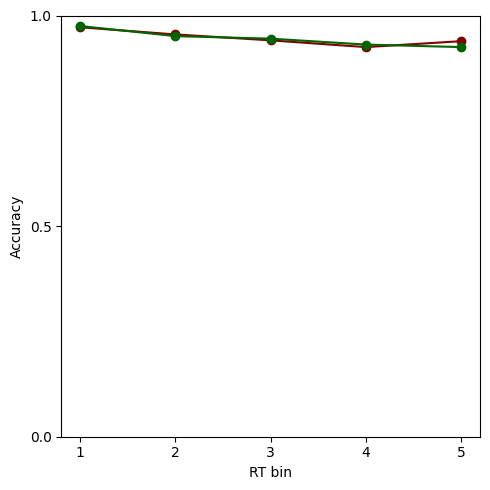

In [24]:
params = dict(
    v_intercept=1.0,
    v_slope_congruent=4.0,
    v_slope_incongruent=4.0,
    s_true_congruent=1.0,
    s_true_incongruent=1.0,
    b=1.2,
    t0=0.3,
)

data = simulate_rdm_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

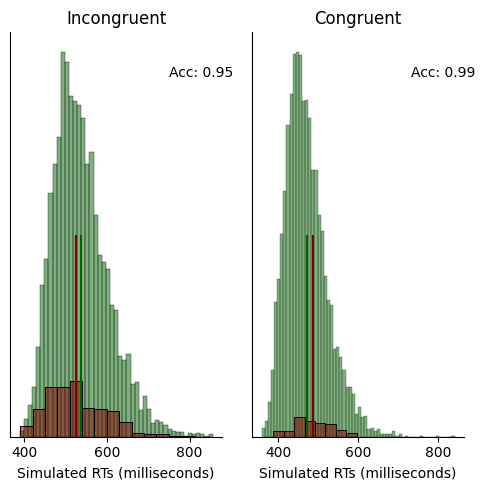

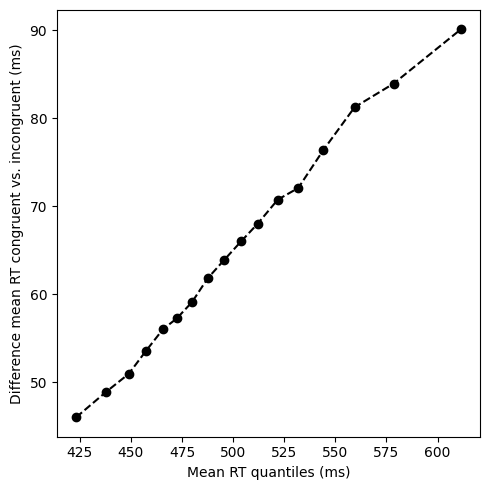

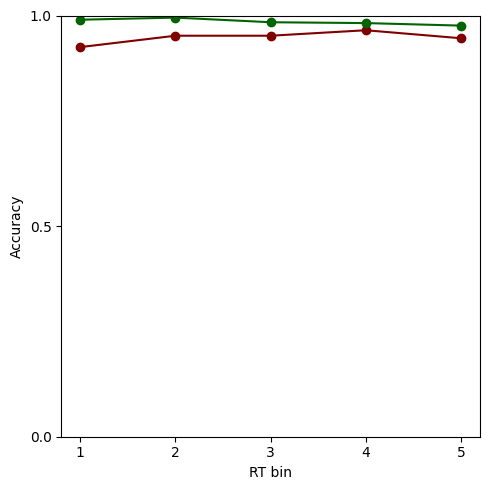

In [25]:
params = dict(
    v_intercept=1.0,
    v_slope_congruent=6.0,
    v_slope_incongruent=4.0,
    s_true_congruent=0.9,
    s_true_incongruent=0.7,
    b=1.2,
    t0=0.3,
)

data = simulate_rdm_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

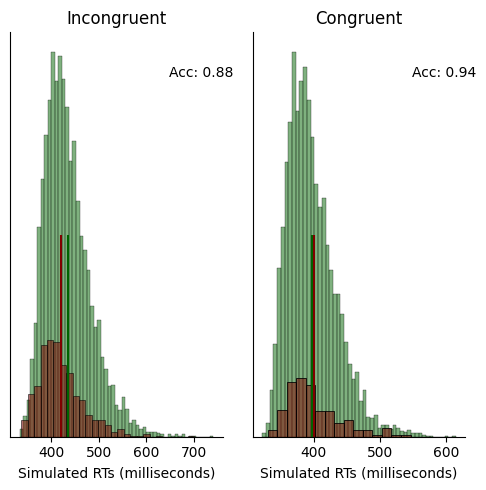

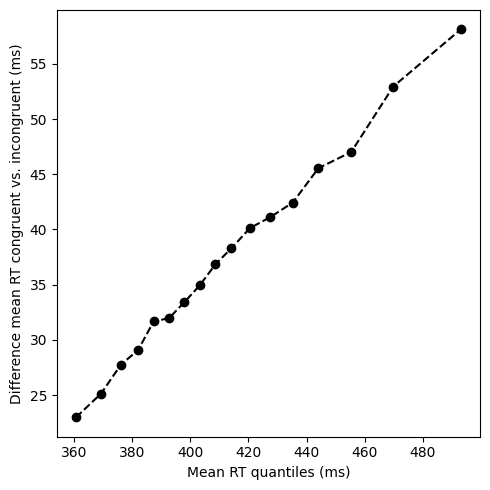

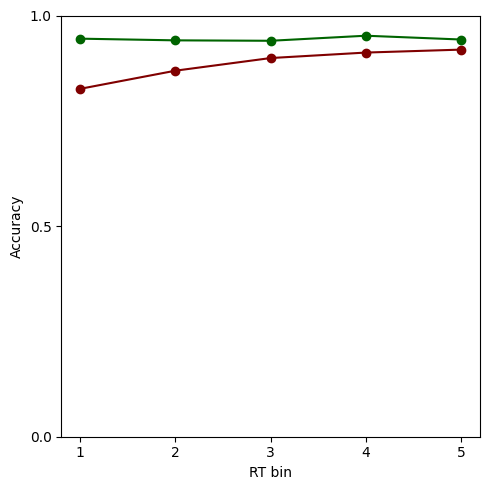

In [26]:
params = dict(
    v_intercept=1.0,
    v_slope_congruent=6.0,
    v_slope_incongruent=4.0,
    s_true_congruent=0.9,
    s_true_incongruent=0.7,
    b=0.7,
    t0=0.3,
)

data = simulate_rdm_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

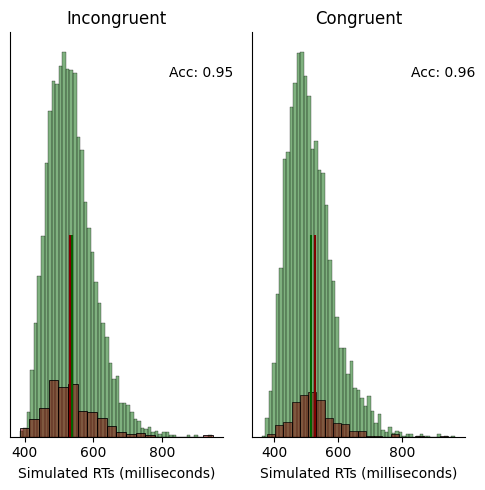

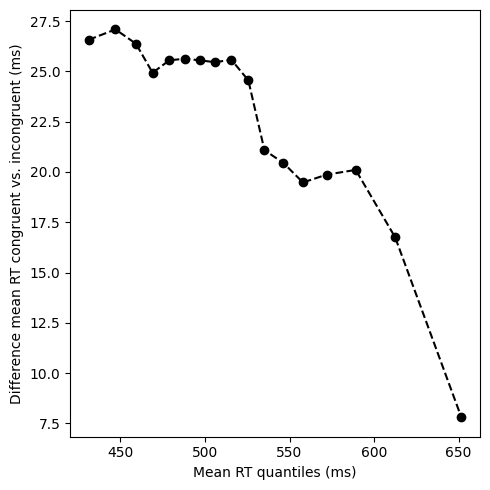

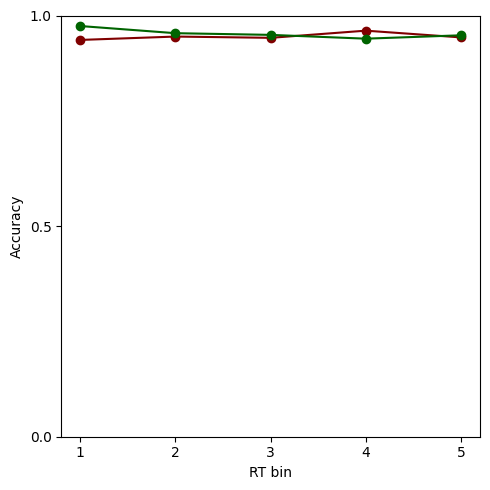

In [27]:
params = dict(
    v_intercept=1.0,
    v_slope_congruent=4.5,
    v_slope_incongruent=4.0,
    s_true_congruent=0.9,
    s_true_incongruent=0.7,
    b=1.2,
    t0=0.3,
)

data = simulate_rdm_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

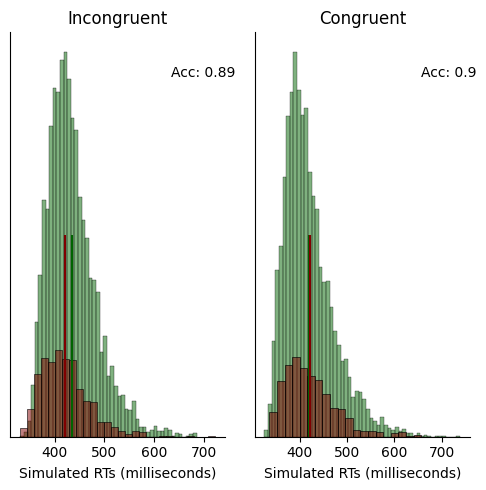

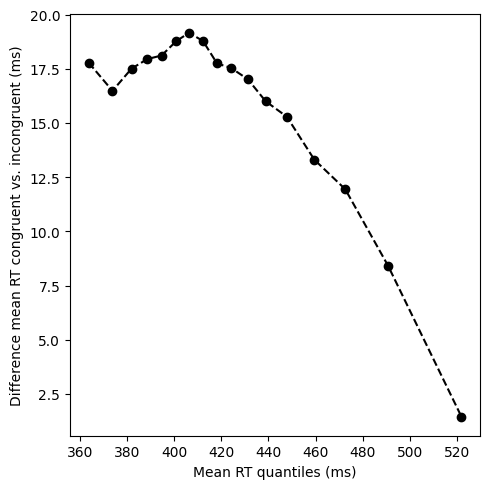

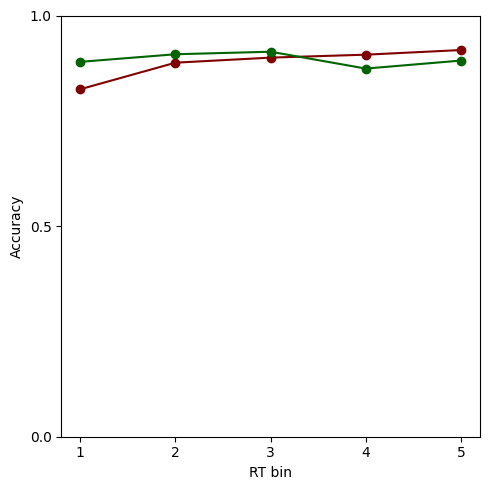

In [28]:
params = dict(
    v_intercept=1.0,
    v_slope_congruent=4.5,
    v_slope_incongruent=4.0,
    s_true_congruent=0.9,
    s_true_incongruent=0.7,
    b=0.7,
    t0=0.3,
)

data = simulate_rdm_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

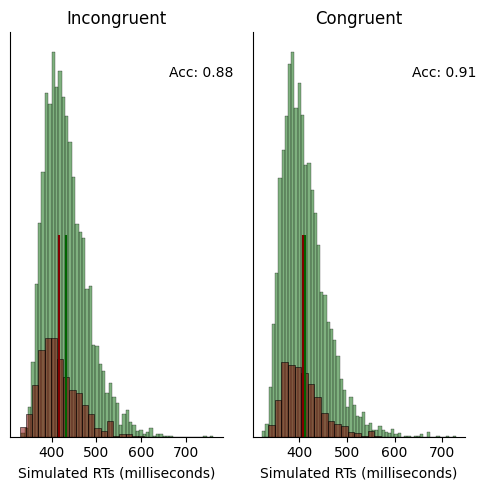

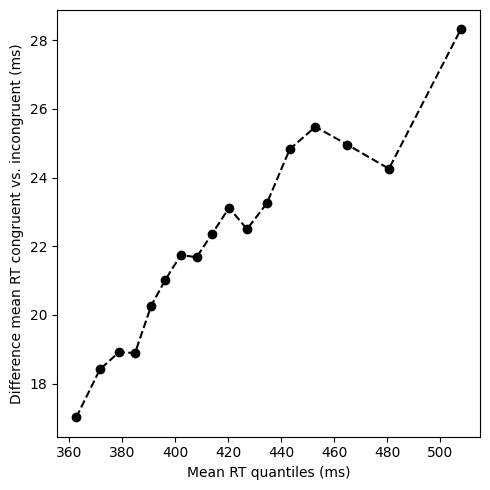

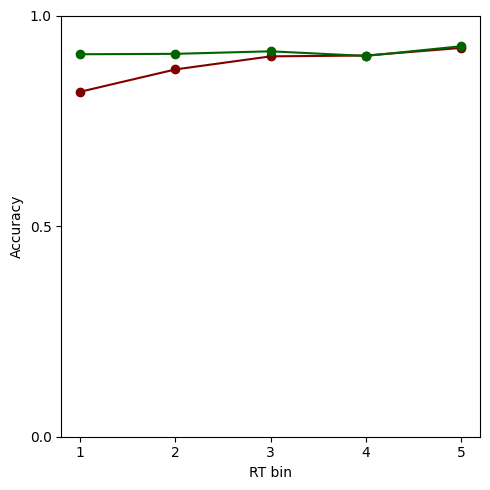

In [29]:
params = dict(
    v_intercept=1.0,
    v_slope_congruent=5.0,
    v_slope_incongruent=4.0,
    s_true_congruent=0.9,
    s_true_incongruent=0.7,
    b=0.7,
    t0=0.3,
)

data = simulate_rdm_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

## CRDM

In [30]:
def simulate_crdm_conditions(**kwargs):
    v_c_congruent = kwargs.pop("v_c_slope_congruent")
    v_c_incongruent = kwargs.pop("v_c_slope_incongruent")
    s_congruent = kwargs.pop("s_true_congruent")
    s_incongruent = kwargs.pop("s_true_incongruent")

    amp = kwargs.pop("amp")

    data_congruent = simulate_rdmc_two_accumulators(
        v_c_slope=v_c_congruent,
        s_true=s_congruent,
        amp=amp,
        s_false=1.0,
        a_shape=2.0,
        num_obs=NUM_OBS // 2,
        t_max=T_MAX,
        **kwargs
    )

    data_incongruent = simulate_rdmc_two_accumulators(
        v_c_slope=v_c_incongruent,
        s_true=s_incongruent,
        amp=-amp,
        num_obs=NUM_OBS // 2,
        s_false=1.0,
        a_shape=2.0,
        t_max=T_MAX,
        **kwargs
    )

    condition = np.repeat([1, 0], data_congruent["x"].shape[0])

    return np.c_[np.vstack([data_congruent["x"], data_incongruent["x"]]), condition]

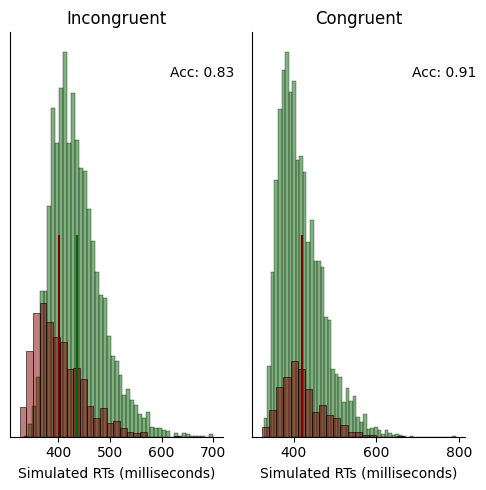

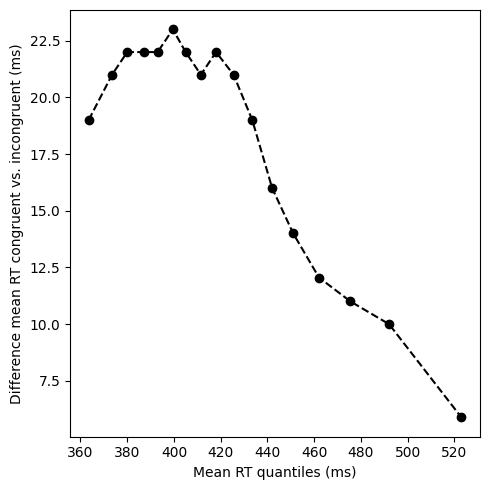

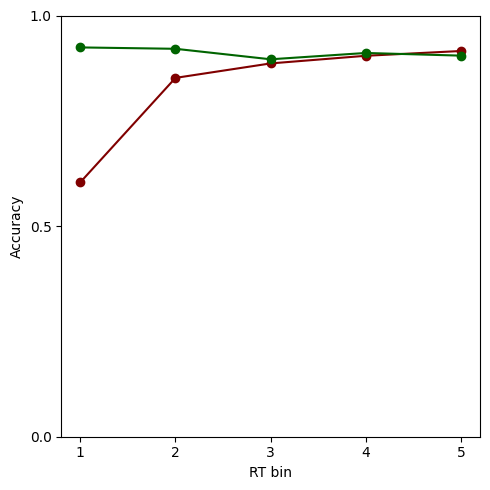

In [41]:
params = dict(
    v_c_intercept=1.0,
    v_c_slope_congruent=4.0,
    v_c_slope_incongruent=4.0,
    amp=0.15,
    tau=0.05,
    s_true_congruent=0.7,
    s_true_incongruent=0.7,
    b=0.7,
    t0=0.3,
)

data = simulate_crdm_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

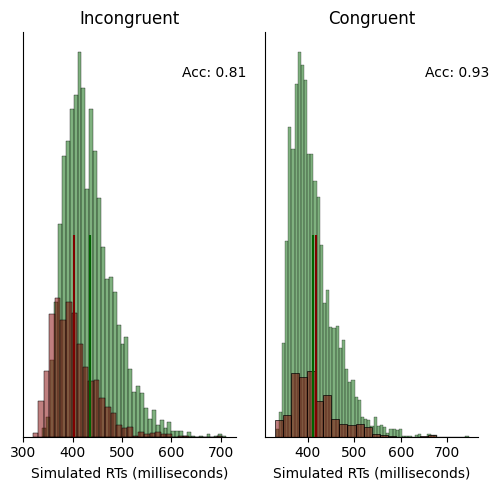

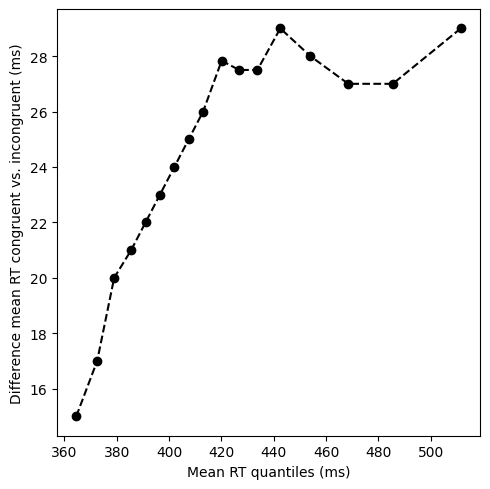

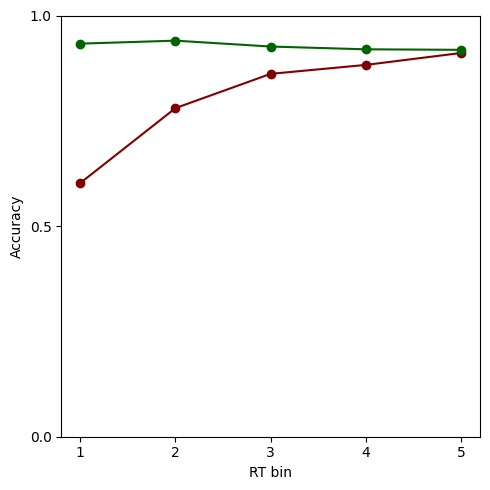

In [14]:
params = dict(
    v_c_intercept=1.0,
    v_c_slope_congruent=4.0,
    v_c_slope_incongruent=4.0,
    amp=0.15,
    tau=0.09,
    s_true_congruent=0.7,
    s_true_incongruent=0.7,
    b=0.7,
    t0=0.3,
)

data = simulate_crdm_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

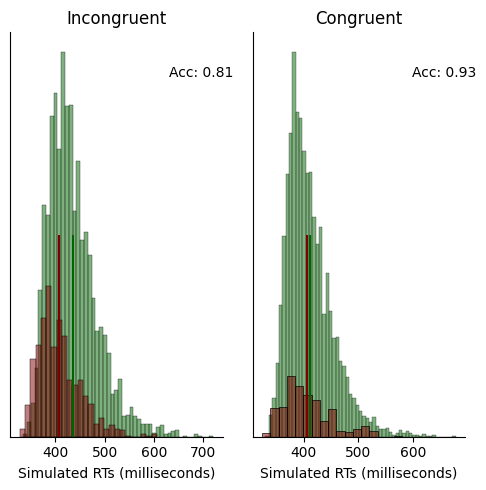

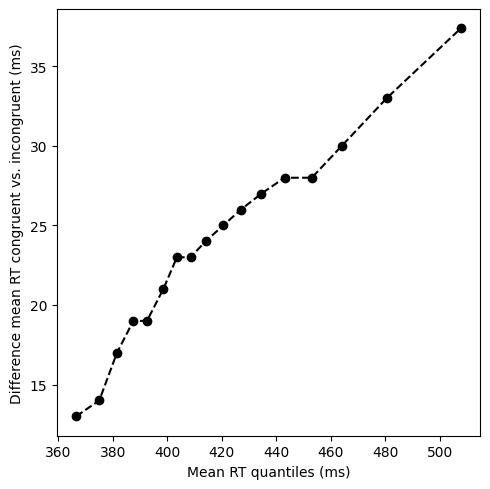

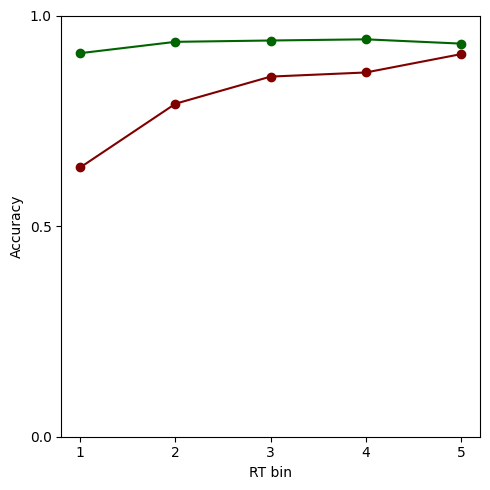

In [15]:
params = dict(
    v_c_intercept=1.0,
    v_c_slope_congruent=4.0,
    v_c_slope_incongruent=4.0,
    amp=0.15,
    tau=0.15,
    s_true_congruent=0.7,
    s_true_incongruent=0.7,
    b=0.7,
    t0=0.3,
)

data = simulate_crdm_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

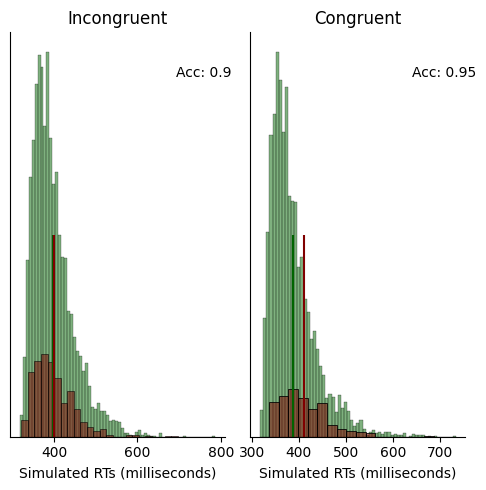

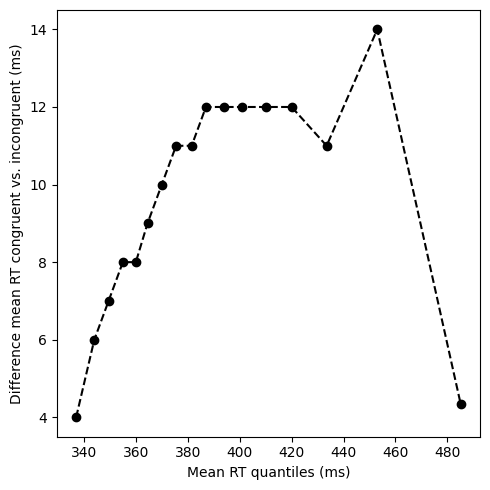

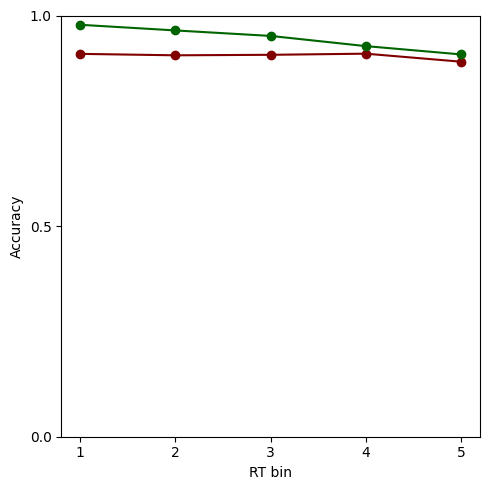

In [48]:
params = dict(
    v_c_intercept=1.0,
    v_c_slope_congruent=6.0,
    v_c_slope_incongruent=6.0,
    amp=0.09,
    tau=0.09,
    s_true_congruent=1.2,
    s_true_incongruent=1.2,
    b=0.7,
    t0=0.3,
)

data = simulate_crdm_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

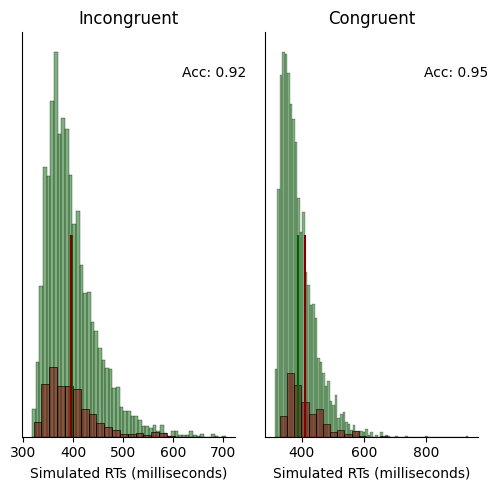

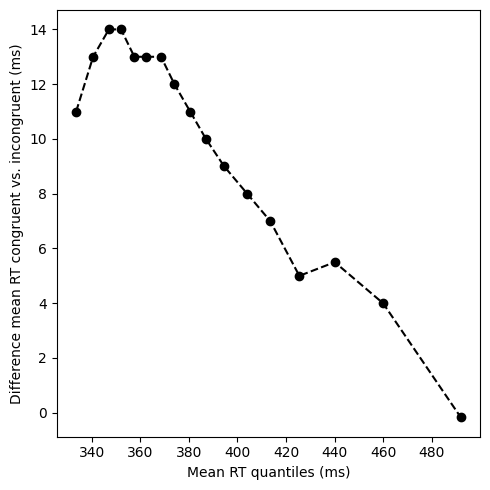

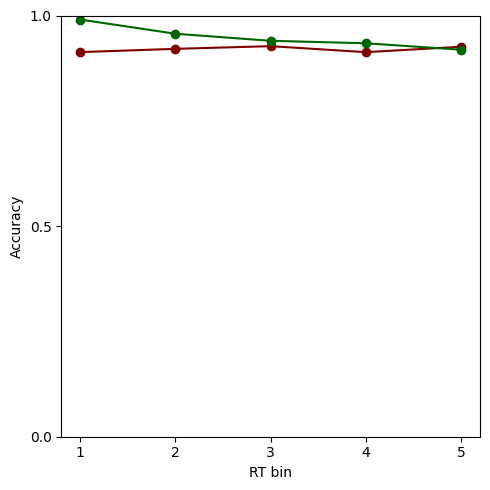

In [46]:
params = dict(
    v_c_intercept=1.0,
    v_c_slope_congruent=6.0,
    v_c_slope_incongruent=6.0,
    amp=0.15,
    tau=0.03,
    s_true_congruent=1.2,
    s_true_incongruent=1.2,
    b=0.7,
    t0=0.3,
)

data = simulate_crdm_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

## DMC

In [18]:
def simulate_dmc_conditions(**kwargs):
    v_c_congruent = kwargs.pop("v_c_congruent")
    v_c_incongruent = kwargs.pop("v_c_incongruent")

    amp = kwargs.pop("amp")

    data_congruent = simulate_dmc(
        v_c=v_c_congruent,
        amp=amp,
        s=1.0,
        alpha=3.0,
        a_shape=2.0,
        num_obs=NUM_OBS // 2,
        t_max=T_MAX,
        **kwargs
    )

    data_incongruent = simulate_dmc(
        v_c=v_c_incongruent,
        amp=-amp,
        s=1.0,
        alpha=3.0,
        a_shape=2.0,
        num_obs=NUM_OBS // 2,
        t_max=T_MAX,
        **kwargs
    )

    condition = np.repeat([1, 0], data_congruent["x"].shape[0])

    return np.c_[np.vstack([data_congruent["x"], data_incongruent["x"]]), condition]

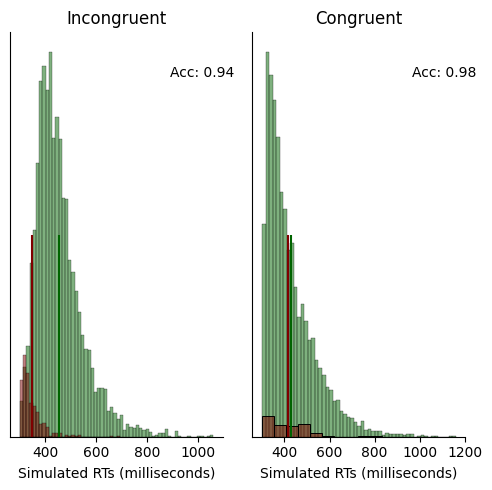

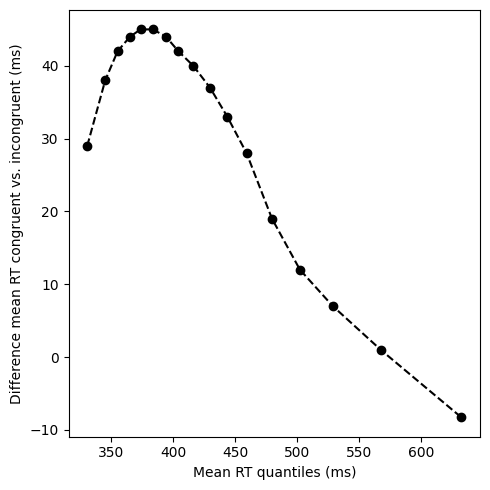

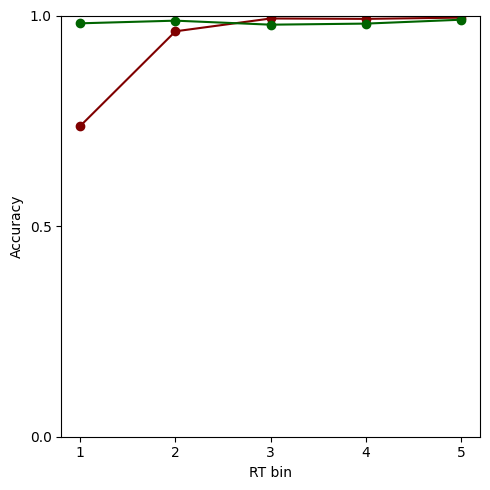

In [19]:
params = dict(
    v_c_congruent=4.0,
    v_c_incongruent=4.0,
    amp=0.15,
    tau=0.05,
    b=0.6,
    t0=0.3,
)

data = simulate_dmc_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

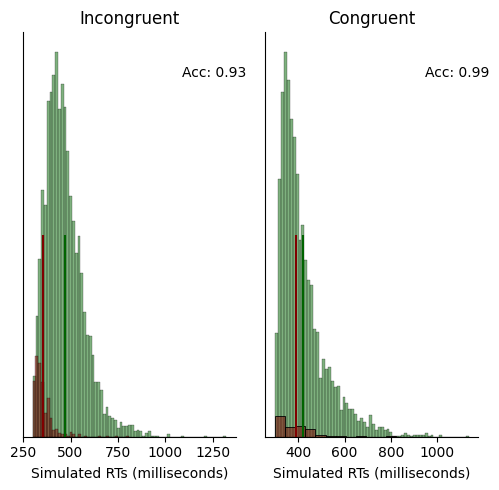

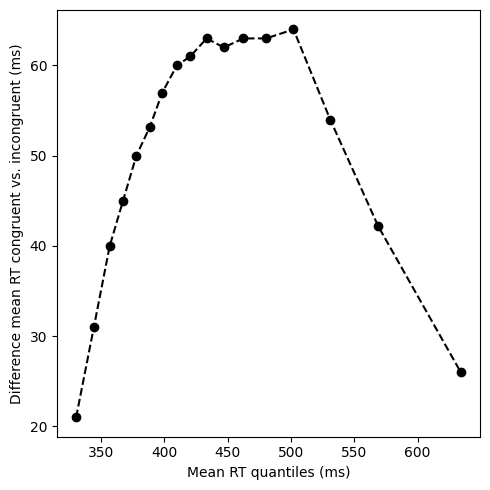

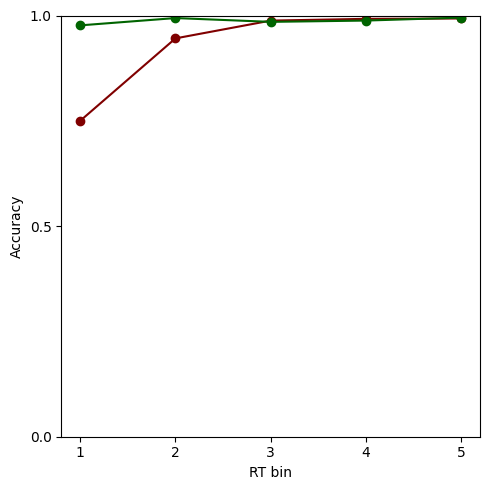

In [20]:
params = dict(
    v_c_congruent=4.0,
    v_c_incongruent=4.0,
    amp=0.15,
    tau=0.09,
    b=0.6,
    t0=0.3,
)

data = simulate_dmc_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)

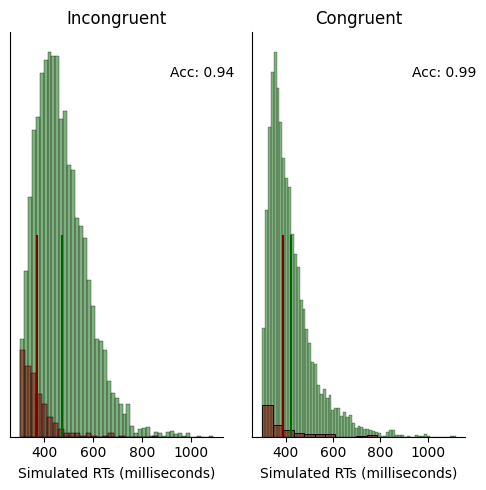

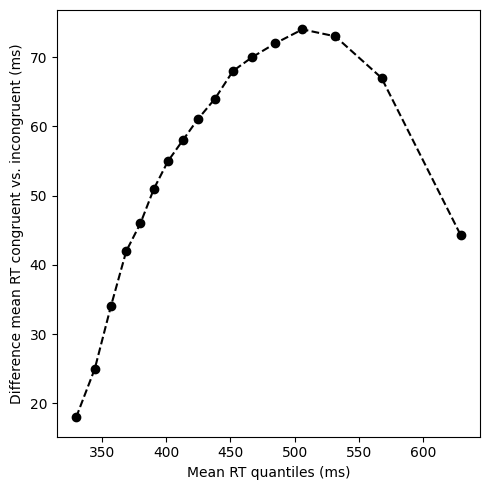

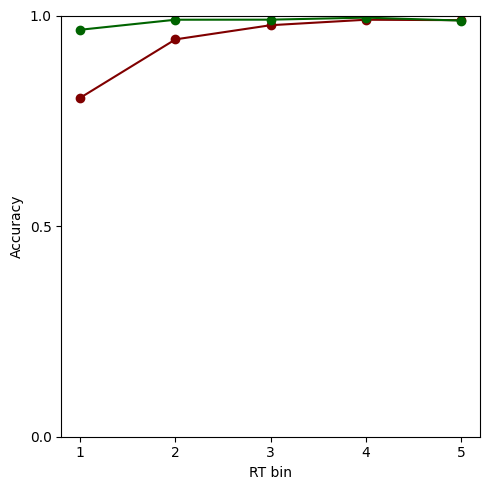

In [21]:
params = dict(
    v_c_congruent=4.0,
    v_c_incongruent=4.0,
    amp=0.15,
    tau=0.15,
    b=0.6,
    t0=0.3,
)

data = simulate_dmc_conditions(**params)

_ = create_pushforward_plot(data)
_ = create_delta_plot(data)
_ = create_caf_plot(data)